In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loading import load_data
from src.model import LinearRegression

In [2]:
df = load_data("../data/raw/train.csv")

print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
y = np.log1p(df["SalePrice"])

x = df.drop(columns=["SalePrice"])

print(x.shape)
print(y.shape)

(1460, 80)
(1460,)


In [4]:
np.random.seed(42)

indices = np.random.permutation(len(x))

val_size = int(len(x) * 0.2)

val_idx = indices[:val_size]
train_idx = indices[val_size:]

x_train = x.iloc[train_idx].reset_index(drop=True)
x_val = x.iloc[val_idx].reset_index(drop=True)

y_train = y.iloc[train_idx].reset_index(drop=True)
y_val = y.iloc[val_idx].reset_index(drop=True)

In [5]:
numeric_cols = x_train.select_dtypes(
    include=[np.number]
).columns

x_train_num = x_train[numeric_cols].copy()
x_val_num = x_val[numeric_cols].copy()

print(len(numeric_cols))

37


In [6]:
medians = x_train_num.median()

x_train_num = x_train_num.fillna(medians)
x_val_num = x_val_num.fillna(medians)

In [7]:
medians = x_train_num.median()

x_train_num = x_train_num.fillna(medians)
x_val_num = x_val_num.fillna(medians)

In [8]:
mean = x_train_num.mean()

std = x_train_num.std(ddof=0)
std = std.replace(0, 1.0)

x_train_num = (x_train_num - mean) / std
x_val_num = (x_val_num - mean) / std

In [9]:
x_train_np = x_train_num.to_numpy(dtype=np.float64)
x_val_np = x_val_num.to_numpy(dtype=np.float64)

y_train_np = y_train.to_numpy(dtype=np.float64)
y_val_np = y_val.to_numpy(dtype=np.float64)

In [10]:
x_train_np = np.hstack(
    [np.ones((x_train_np.shape[0], 1)), x_train_np]
)

x_val_np = np.hstack(
    [np.ones((x_val_np.shape[0], 1)), x_val_np]
)

print(x_train_np.shape)

(1168, 38)


In [11]:
ridge = LinearRegression(
    lr=0.01,
    n_epochs=1000,
    reg_lambda=0.01
)

ridge.fit(
    x_train_np,
    y_train_np,
    x_val_np,
    y_val_np,
    verbose=True
)

Epoch    0 | train_loss = 139.027691 | val_loss = 138.321927
Epoch  100 | train_loss = 2.465173 | val_loss = 2.472597
Epoch  200 | train_loss = 0.064514 | val_loss = 0.066824
Epoch  300 | train_loss = 0.022066 | val_loss = 0.024082
Epoch  400 | train_loss = 0.021232 | val_loss = 0.023319
Epoch  500 | train_loss = 0.021178 | val_loss = 0.023331
Epoch  600 | train_loss = 0.021158 | val_loss = 0.023352
Epoch  700 | train_loss = 0.021147 | val_loss = 0.023368
Epoch  800 | train_loss = 0.021141 | val_loss = 0.023378
Epoch  900 | train_loss = 0.021138 | val_loss = 0.023385
Epoch  999 | train_loss = 0.021136 | val_loss = 0.023390


In [12]:
train_pred = ridge.predict(x_train_np)

val_pred = ridge.predict(x_val_np)

In [13]:
def rmse(y, yhat):
    return np.sqrt(np.mean((yhat - y) ** 2))

train_rmse = rmse(y_train_np, train_pred)
val_rmse = rmse(y_val_np, val_pred)

print("Train RMSE:", train_rmse)
print("Val RMSE:", val_rmse)

Train RMSE: 0.1440776283184795
Val RMSE: 0.15170037148356424


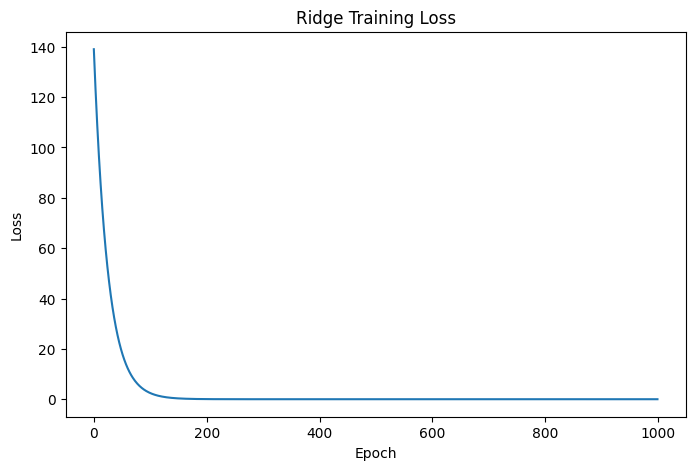

In [14]:
plt.figure(figsize=(8,5))

plt.plot(ridge.loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Ridge Training Loss")

plt.show()

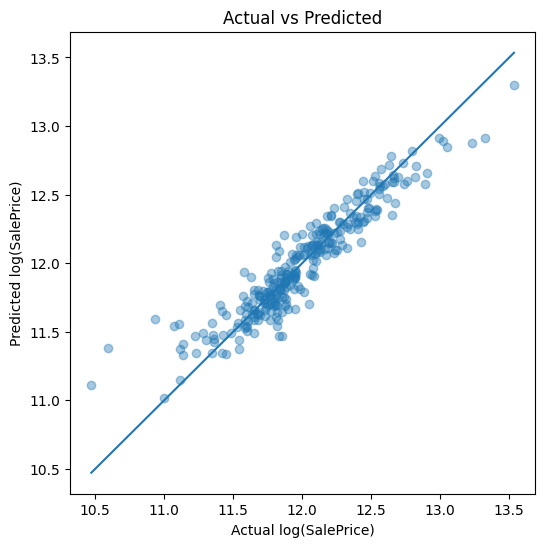

In [15]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_val_np,
    val_pred,
    alpha=0.4
)

mn = min(y_val_np.min(), val_pred.min())
mx = max(y_val_np.max(), val_pred.max())

plt.plot(
    [mn, mx],
    [mn, mx]
)

plt.xlabel("Actual log(SalePrice)")
plt.ylabel("Predicted log(SalePrice)")
plt.title("Actual vs Predicted")

plt.show()

In [16]:
lambdas = [
    0.0,
    0.001,
    0.01,
    0.1,
    1.0
]

results = []

for lam in lambdas:

    model = LinearRegression(
        lr=0.01,
        n_epochs=1000,
        reg_lambda=lam
    )

    model.fit(
        x_train_np,
        y_train_np,
        verbose=False
    )

    val_pred = model.predict(x_val_np)

    val_rmse = rmse(
        y_val_np,
        val_pred
    )

    results.append(
        (lam, val_rmse)
    )

results

[(0.0, np.float64(0.15178507009464312)),
 (0.001, np.float64(0.15177430826167962)),
 (0.01, np.float64(0.15170037148356424)),
 (0.1, np.float64(0.15229637943568244)),
 (1.0, np.float64(0.17321510897509812))]

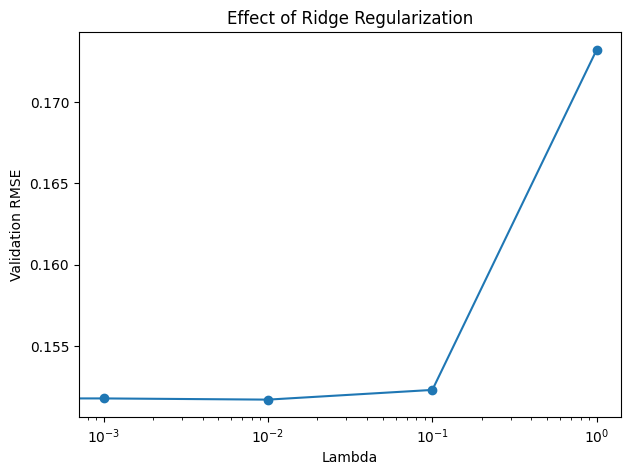

In [17]:
lams = [x[0] for x in results]
scores = [x[1] for x in results]

plt.figure(figsize=(7,5))

plt.plot(
    lams,
    scores,
    marker="o"
)

plt.xscale("log")

plt.xlabel("Lambda")
plt.ylabel("Validation RMSE")

plt.title("Effect of Ridge Regularization")

plt.show()